### PySpark Otomoto Demo 

Źródło danych: https://www.kaggle.com/datasets/szymoncyperski/car-sales-offers-from-otomotopl-2023 


In [1]:
import os
import subprocess
from pathlib import Path


os.environ["JAVA_HOME"] = "/opt/homebrew/opt/openjdk@17/libexec/openjdk.jdk/Contents/Home"

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
import matplotlib.pyplot as plt


**Teoria:** Powyżej importujemy niezbędne biblioteki. `SparkSession` to główny punkt wejścia do funkcjonalności DataFrame i SQL w Sparku (od wersji 2.0). Moduł `functions` dostarcza wbudowane funkcje operujące na kolumnach, a `matplotlib.pyplot` posłuży nam do późniejszej wizualizacji danych.


In [2]:
spark = SparkSession.builder \
    .appName("Otomoto Demo") \
    .getOrCreate()


Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/05/16 23:30:09 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


**Teoria:** Tworzymy sesję Sparka. `builder` używa wzorca projektowego Builder do skonfigurowania sesji. `getOrCreate()` tworzy nową sesję lub pobiera istniejącą, co jest bezpieczne przy wielokrotnym uruchamianiu notatnika.


In [3]:
df = spark.read.option("header", True) \
    .option("delimiter", ";") \
    .option("inferSchema", False) \
    .csv("otomoto_offers_eng_23-04-2023.csv")


**Teoria:** Wczytywanie danych. Spark używa leniwego ewaluowania (lazy evaluation) - dane nie są fizycznie wczytywane w tym momencie, tworzony jest tylko plan wykonania (DAG). Ustawiamy `header=True` ponieważ nasz plik CSV ma nagłówki, oraz określamy separator jako średnik `;`.


In [4]:
df.show()

26/05/16 23:30:12 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


+----------+-------------------+--------------------+------+--------+-----------------+------------------------+--------------------+---------------+--------+---------------------------+-------------+-------------+---------------+---------------+----------+-------------------+--------------+------+------------+-------------+---------------+---------------+---------+----------+---------------------+-----+--------------------+------------------------+----------+-----+---------------------------+------------+-----------+--------------------------+--------------------------+--------------+-------------+----------------------+----------------------------------+----------------------------+----------------------+---------------------+--------------+------------------------------------+-------------------+----------------+--------------+---------------+------------+----+-------------------+-------------+----------------+------------------+------------------+------------------+----------------

**Teoria:** `show()` to akcja (action), która uruchamia wykonanie obliczeń w Sparku. Dopiero teraz plik jest odczytywany, a wynik prezentowany na ekranie.


In [5]:
df.filter(F.col("vehicle_brand") == "Volvo").show()

+----------+-------------------+--------------------+------+--------+-----------------+------------------------+--------------------+---------------+--------+---------------------------+-------------+-------------+-------------+---------------+----------+-------------------+---------+------+------------+-------------+---------------+---------------+--------+----------+---------------------+-----+--------------------+------------------------+----------+-----+---------------------------+------------+-----------+--------------------------+--------------------------+--------------+-------------+----------------------+----------------------------------+----------------------------+----------------------+---------------------+--------------+------------------------------------+-------------------+----------------+--------------+---------------+------------+----+-------------------+-------------+----------------+------------------+------------------+------------------+-----------------+------

In [6]:
df = df.withColumn("price_num",
                   F.regexp_replace(F.col("price"), r"[^\d]", "").cast("double"))

df = df.withColumn("mileage_km",
                   F.regexp_replace(F.col("mileage"), r"[^\d]", "").cast("integer"))

df = df.withColumn("production_year_int",
                   F.regexp_replace(F.col("production_year"), r"[^\d]", "").cast("integer"))

df = df.withColumn("engine_cc",
                   F.regexp_replace(F.col("engine_displacement"), r"[^\d]", "").cast("integer"))

df = df.withColumn("power_hp",
                   F.regexp_replace(F.col("power"), r"[^\d]", "").cast("integer"))

df = df.withColumn("fuel_clean",
                   F.lower(F.trim(F.col("fuel_type"))))

In [7]:
df.select("vehicle_brand", "vehicle_model", "price_num", "mileage_km",
          "production_year_int", "engine_cc", "power_hp", "fuel_clean") \
  .show(10, truncate=False)

+-------------+-------------+---------+----------+-------------------+---------+--------+--------------+
|vehicle_brand|vehicle_model|price_num|mileage_km|production_year_int|engine_cc|power_hp|fuel_clean    |
+-------------+-------------+---------+----------+-------------------+---------+--------+--------------+
|Volvo        |V70          |23200.0  |304000    |2010               |15603    |109     |diesel        |
|Honda        |Accord       |16800.0  |236000    |2005               |19983    |155     |gasoline      |
|Mercedes-Benz|Klasa X      |249900.0 |73000     |2019               |29873    |258     |diesel        |
|Toyota       |Avensis      |16499.0  |220000    |2005               |17943    |129     |gasoline      |
|Ford         |C-MAX        |29900.0  |179058    |2012               |19973    |140     |diesel        |
|Peugeot      |208          |80900.0  |1         |2023               |11993    |75      |gasoline      |
|Kia          |Sportage     |74770.0  |100420    |2018 

**Teoria:** `select()` to transformacja, która działa jak w SQL - pozwala wybrać podzbiór kolumn. Zmniejsza to ilość przetwarzanych danych w dalszych krokach.


In [8]:
avg_brand = df.groupBy("vehicle_brand") \
              .agg(F.round(F.avg("price_num"), 2).alias("avg_price")) \
              .orderBy(F.col("avg_price").desc())

print("Średnia cena per marka")
avg_brand.show(20, truncate=False)

Średnia cena per marka
+-------------+----------+
|vehicle_brand|avg_price |
+-------------+----------+
|Lamborghini  |1281601.59|
|Ferrari      |1015648.41|
|McLaren      |866462.12 |
|Rolls-Royce  |762649.96 |
|Bentley      |657051.57 |
|Maybach      |575529.83 |
|Aston Martin |530891.29 |
|KTM          |389000.0  |
|Porsche      |363902.5  |
|Alpine       |352555.5  |
|RAM          |348905.66 |
|Geely        |346903.0  |
|BMW-ALPINA   |333006.94 |
|LEVC         |305776.0  |
|Skywell      |274743.33 |
|Maxus        |255052.59 |
|Tesla        |232544.92 |
|Caterham     |227550.0  |
|Land Rover   |200495.64 |
|Maserati     |197591.6  |
+-------------+----------+
only showing top 20 rows


In [9]:
fuel_count = df.groupBy("fuel_clean").count()
print("Liczba ogłoszeń wg rodzaju paliwa")
fuel_count.show()

Liczba ogłoszeń wg rodzaju paliwa
+--------------+------+
|    fuel_clean| count|
+--------------+------+
|      gasoline|101165|
|        diesel| 88624|
|gasoline + lpg|  7419|
|        hybrid|  7527|
|gasoline + cng|    96|
|      electric|  3373|
|      hydrogen|     1|
+--------------+------+



In [10]:
df.createOrReplaceTempView("cars")

In [11]:
# SQL: zależność mocy i pojemności od ceny
spark.sql("""
    SELECT vehicle_brand,
           ROUND(AVG(power_hp), 1) AS avg_power,
           ROUND(AVG(engine_cc), 1) AS avg_cc,
           ROUND(AVG(price_num), 1) AS avg_price
    FROM cars
    GROUP BY vehicle_brand
    ORDER BY avg_power DESC
""").show()

+-------------+---------+-------+---------+
|vehicle_brand|avg_power| avg_cc|avg_price|
+-------------+---------+-------+---------+
|      McLaren|    652.5|38811.5| 866462.1|
|  Lamborghini|    637.8|51767.4|1281601.6|
|      Ferrari|    632.9|46168.3|1015648.4|
|      Bentley|    550.8|54644.1| 657051.6|
|      Maybach|    541.0|53499.7| 575529.8|
| Aston Martin|    528.1|48457.7| 530891.3|
|   BMW-ALPINA|    516.0|40259.4| 333006.9|
|        Tesla|    486.4| 6023.0| 232544.9|
|  Rolls-Royce|    479.7|65997.4| 762650.0|
|          RAM|    413.2|55898.3| 348905.7|
|     Polestar|    408.0|   NULL| 146750.0|
|     Maserati|    397.7|31911.3| 197591.6|
|      Porsche|    376.8|33072.8| 363902.5|
|          KTM|    362.0|19843.0| 389000.0|
|        Dodge|    341.5|46547.9| 142202.8|
|      Genesis|    336.3|31915.5| 108725.0|
|     Cadillac|    309.1|47372.8| 140824.6|
|          GMC|    290.3|50369.8| 135253.3|
|     Plymouth|    287.5|50298.0| 125230.0|
|       Hummer|    278.3|49413.6

In [12]:
df.groupBy("production_year_int") \
  .count() \
  .orderBy(F.col("production_year_int").desc()) \
  .show()

+-------------------+-----+
|production_year_int|count|
+-------------------+-----+
|               2023|12987|
|               2022|13680|
|               2021| 7729|
|               2020| 7787|
|               2019|13978|
|               2018|15096|
|               2017|13952|
|               2016|11755|
|               2015|10640|
|               2014| 9988|
|               2013| 9341|
|               2012| 9664|
|               2011|10108|
|               2010| 9115|
|               2009| 9040|
|               2008| 8846|
|               2007| 7816|
|               2006| 6320|
|               2005| 5121|
|               2004| 3647|
+-------------------+-----+
only showing top 20 rows


In [13]:
# Średnia cena i przebieg per marka i model
df.groupBy("vehicle_brand", "vehicle_model") \
  .agg(
      F.round(F.avg("price_num"), 2).alias("avg_price"),
      F.round(F.avg("mileage_km"), 2).alias("avg_mileage")
  ) \
  .orderBy(F.col("avg_price").desc()) \
  .show(20, truncate=False)

+-------------+-------------+----------+-----------+
|vehicle_brand|vehicle_model|avg_price |avg_mileage|
+-------------+-------------+----------+-----------+
|Ferrari      |812 GTS      |2750000.0 |2000.0     |
|Mercedes-Benz|SLR          |2340000.0 |2380.0     |
|Ferrari      |SF90 Stradale|2293626.0 |1855.75    |
|Rolls-Royce  |Dawn         |1999999.0 |4300.0     |
|Lamborghini  |Aventador    |1822661.67|14467.5    |
|Ferrari      |812 Superfast|1670200.0 |16414.0    |
|Lamborghini  |Murcielago   |1550000.0 |46950.0    |
|McLaren      |Artura       |1499000.0 |2100.0     |
|McLaren      |675Lt        |1290000.0 |18500.0    |
|McLaren      |600lt-coupe  |1289000.0 |8500.0     |
|Lamborghini  |Huracan      |1258737.0 |25671.46   |
|Rolls-Royce  |Phantom      |1225000.0 |22000.0    |
|Rolls-Royce  |Ghost        |1206316.67|39451.67   |
|Bentley      |Bentayga     |1200222.11|34022.72   |
|Lamborghini  |Diablo       |1199900.0 |32164.0    |
|Rolls-Royce  |Wraith       |1183000.0 |54333.

In [14]:
# zależność ceny od przebiegu 
price_mileage = df.select("price_num", "mileage_km") \
                  .where((F.col("price_num").isNotNull()) & (F.col("mileage_km").isNotNull()))

Wizualizacja scatter zapisana jako scatter_price_mileage.png


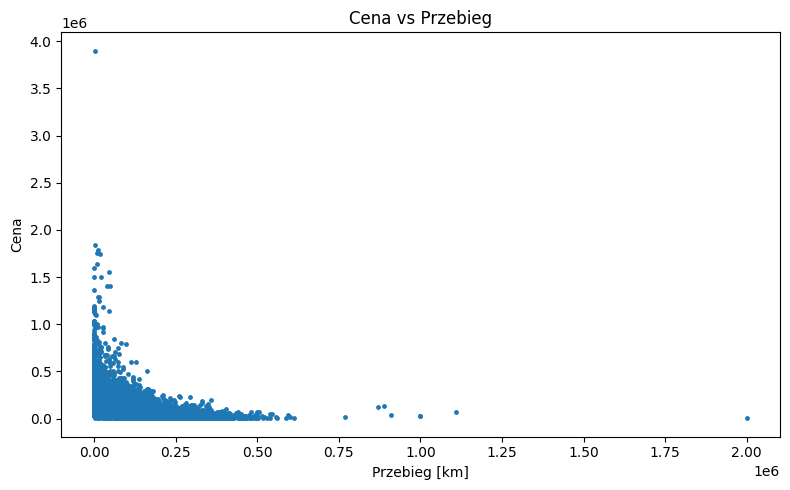

In [15]:
pdf_scatter = price_mileage.sample(fraction=0.1, seed=42).toPandas()

plt.figure(figsize=(8,5))
plt.scatter(pdf_scatter["mileage_km"], pdf_scatter["price_num"], s=6)
plt.title("Cena vs Przebieg")
plt.xlabel("Przebieg [km]")
plt.ylabel("Cena")
plt.tight_layout()
plt.savefig("scatter_price_mileage.png")

print("Wizualizacja scatter zapisana jako scatter_price_mileage.png")

**Teoria:** `toPandas()` to akcja, która zbiera (collect) wszystkie dane na partycjach roboczych i przesyła je na węzeł główny (Driver), konwertując do struktury Pandas DataFrame. Uwaga: Można tego używać tylko na małych zbiorach (po limitowaniu np. top 10), w przeciwnym razie braknie pamięci RAM na Driverze!


---
# Zadanie samodzielne: Analiza Przestępczości w Chicago

Poniżej znajduje się miejsce na realizację zadania z analizy danych przy użyciu PySpark na zbiorze *Chicago Crimes* (około 50 000 ostatnich zdarzeń). Twoim celem jest przygotowanie, wyczyszczenie oraz zanalizowanie tych danych z wykorzystaniem zaawansowanych optymalizacji dostępnych w Sparku.

### Wymagania:
1. **Wczytanie i Czyszczenie Danych:** Wczytaj pobrany plik `chicago_crimes_sample.csv`. Usuń ewentualne duplikaty, wiersze z brakami danych (szczególnie w kluczowych kolumnach) i odfiltruj/napraw błędne daty.
2. **UDF i Pora Dnia:** Dodaj nową kolumnę z klasyfikacją pory dnia (np. noc, dzień, wieczór) utworzoną za pomocą User Defined Function (UDF) w oparciu o godzinę z kolumny `Date`.
3. **Optymalizacja i Partycjonowanie:** Zoptymalizuj przetwarzanie. Zastanów się, w których momentach użyć `cache()`. Przy dołączaniu mniejszych tabel słownikowych (jeśli byś je tworzył), wykorzystaj *broadcast join*. Ostatecznie zapisz przefiltrowane dane do formatu **Parquet** z podziałem na partycje według roku (`Year`).
4. **Analiza i Plany Zapytań:** Przeprowadź analizę statystyczną przestępstw (np. jakiego typu przestępstwa są najpopularniejsze w konkretnych lokacjach, o konkretnym czasie). Wykorzystaj funkcję `.explain()` aby udokumentować plan zapytania Sparka dla najcięższej agregacji.
5. *(Opcjonalnie)* **Uczenie Maszynowe (MLlib):** Spróbuj zbudować i wytrenować prosty model wieloklasowy, przewidujący rodzaj przestępstwa (`Primary Type`) na podstawie innych atrybutów, jak lokacja, godzina, arrest itp.

In [ ]:
import os
import subprocess
from pathlib import Path

os.environ["JAVA_HOME"] = "/opt/homebrew/opt/openjdk@17/libexec/openjdk.jdk/Contents/Home"

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
import matplotlib.pyplot as plt

from pyspark.sql.types import StringType
from pyspark.sql.functions import broadcast, udf
from pyspark import SparkContext

# bez tego getOrCreate() daje Connection refused
try:
    _s = SparkSession.getActiveSession()
    if _s is not None:
        _s.stop()
except Exception:
    pass
try:
    if SparkContext._active_spark_context is not None:
        SparkContext._active_spark_context.stop()
except Exception:
    pass

spark = SparkSession.builder \
    .appName("Chicago Crimes") \
    .config("spark.driver.memory", "4g") \
    .getOrCreate()

df_crimes = spark.read.option("header", True) \
    .option("delimiter", ",") \
    .option("inferSchema", False) \
    .option("multiLine", True) \
    .csv("chicago_crimes_sample.csv")

df_crimes.show(5, truncate=False)

rename_map = {"Primary Type": "primary_type", "Date": "date"}
for old, new in rename_map.items():
    if old in df_crimes.columns:
        df_crimes = df_crimes.withColumnRenamed(old, new)

df_crimes = df_crimes.withColumn(
    "primary_type_clean",
    F.lower(F.trim(F.col("primary_type"))),
)

df_crimes = df_crimes.withColumn(
    "arrest_clean",
    F.lower(F.trim(F.col("arrest"))),
)

df_crimes = df_crimes.withColumn(
    "domestic_clean",
    F.lower(F.trim(F.col("domestic"))),
)

df_crimes = df_crimes.withColumn(
    "date_ts",
    F.coalesce(
        F.to_timestamp(F.col("date"), "yyyy-MM-dd'T'HH:mm:ss.SSS"),
        F.to_timestamp(F.col("date"), "yyyy-MM-dd'T'HH:mm:ss"),
        F.to_timestamp(F.col("date")),
    ),
)

df_crimes = df_crimes.withColumn(
    "year_int",
    F.regexp_replace(F.col("year"), r"[^\d]", "").cast("integer"),
)

key_cols = [c for c in ["date_ts", "primary_type_clean", "year_int"] if c in df_crimes.columns]
df_crimes = df_crimes.dropna(subset=key_cols)

df_crimes = df_crimes.filter(
    F.col("year_int").between(2000, 2030)
    & (F.year(F.col("date_ts")) == F.col("year_int"))
)

dedup_cols = ["id"] if "id" in df_crimes.columns else ["case_number", "date_ts"]
df_crimes = df_crimes.dropDuplicates(dedup_cols)

df_crimes.filter(F.col("domestic_clean") == "true") \
    .select("primary_type_clean", "block", "district") \
    .show(5, truncate=False)

df_crimes = df_crimes.withColumn("hour", F.hour(F.col("date_ts")))

def _pora_dnia(hour):
    """Klasyfikacja pory dnia na podstawie godziny (0–23)."""
    if hour is None:
        return None
    try:
        h = int(hour)
    except (TypeError, ValueError):
        return None
    if h >= 22 or h < 6:
        return "noc"
    if h < 12:
        return "ranek"
    if h < 18:
        return "dzień"
    return "wieczór"


pora_udf = udf(_pora_dnia, StringType())
df_crimes = df_crimes.withColumn("pora_dnia", pora_udf(F.col("hour")))

df_crimes.cache()

_district_region = [
    ("001", "Central"),
    ("002", "Central"),
    ("003", "South"),
    ("008", "Southwest"),
    ("009", "Southwest"),
    ("018", "Central"),
]
district_lookup = spark.createDataFrame(_district_region, ["district", "region"])

df_crimes = df_crimes.join(
    broadcast(district_lookup),
    on="district",
    how="left",
).withColumn("region", F.coalesce(F.col("region"), F.lit("inne")))

df_crimes.createOrReplaceTempView("crimes")

df_parquet = df_crimes.drop("year").withColumn("year", F.col("year_int"))
df_parquet.write.mode("overwrite").partitionBy("year").parquet("chicago_crimes_clean.parquet")

print("Wiersze po czyszczeniu:", df_crimes.count())

df_crimes.select(
    "id",
    "primary_type_clean",
    "location_description",
    "pora_dnia",
    "district",
    "region",
).show(10, truncate=False)

print("Rozkład pór dnia:")
df_crimes.groupBy("pora_dnia") \
    .count() \
    .orderBy(F.col("count").desc()) \
    .show()

spark.sql("""
    SELECT location_description,
           primary_type_clean AS primary_type,
           pora_dnia,
           COUNT(*) AS cnt
    FROM crimes
    GROUP BY location_description, primary_type_clean, pora_dnia
    ORDER BY cnt DESC
    LIMIT 15
""").show(truncate=False)

heavy_agg = df_crimes.groupBy("location_description", "primary_type_clean", "pora_dnia") \
    .agg(F.count(F.lit(1)).alias("cnt")) \
    .orderBy(F.desc("cnt"))

print("Plan zapytania (extended) dla agregacji location_description × primary_type × pora_dnia:")
heavy_agg.explain(mode="extended")
heavy_agg.show(15, truncate=False)

df_crimes.groupBy("region") \
    .agg(
        F.round(F.avg("hour"), 2).alias("avg_hour"),
        F.count(F.lit(1)).alias("cnt"),
    ) \
    .orderBy(F.col("cnt").desc()) \
    .show(15, truncate=False)

# Opcjonalnie Zad 5.
try:
    from pyspark.ml import Pipeline
    from pyspark.ml.classification import RandomForestClassifier
    from pyspark.ml.feature import StringIndexer, VectorAssembler

    ml_base = (
        df_crimes.select(
            F.col("primary_type_clean").alias("label_raw"),
            F.col("hour").cast("double"),
            F.when(F.col("arrest_clean") == "true", 1.0).otherwise(0.0).alias("arrest_f"),
            F.when(F.col("domestic_clean") == "true", 1.0).otherwise(0.0).alias("domestic_f"),
            F.col("district"),
        )
        .dropna(subset=["label_raw", "district"])
        .sample(0.35, seed=42)
    )

    idx_label = StringIndexer(inputCol="label_raw", outputCol="label", handleInvalid="skip")
    idx_dist = StringIndexer(inputCol="district", outputCol="district_idx", handleInvalid="skip")
    vec = VectorAssembler(
        inputCols=["hour", "arrest_f", "domestic_f", "district_idx"],
        outputCol="features",
    )
    rf = RandomForestClassifier(
        labelCol="label",
        featuresCol="features",
        numTrees=10,
        maxDepth=6,
        maxBins=64,
        seed=42,
    )
    pipe = Pipeline(stages=[idx_label, idx_dist, vec, rf])
    train_df, test_df = ml_base.randomSplit([0.8, 0.2], seed=42)
    rf_model = pipe.fit(train_df)
    evaluated = rf_model.transform(test_df)
    acc = evaluated.filter(F.col("prediction") == F.col("label")).count() / evaluated.count()
    print(f"Dokładność RandomForest (test, orientacyjnie): {acc:.4f}")
except Exception as _ml_exc:
    print("ML opcjonalnie — pominięty lub błąd:", _ml_exc)

df_crimes.unpersist()



+--------+-----------+-----------------------+---------------------+----+------------+---------------------------------------+---------------------+------+--------+----+--------+----+--------------+--------+------------+------------+----+-----------------------+------------+-------------+------------------------------------+
|id      |case_number|date                   |block                |iucr|primary_type|description                            |location_description |arrest|domestic|beat|district|ward|community_area|fbi_code|x_coordinate|y_coordinate|year|updated_on             |latitude    |longitude    |location                            |
+--------+-----------+-----------------------+---------------------+----+------------+---------------------------------------+---------------------+------+--------+----+--------+----+--------------+--------+------------+------------+----+-----------------------+------------+-------------+------------------------------------+
|14193193|JK249780 

26/05/16 23:30:20 WARN MemoryManager: Total allocation exceeds 95.00% (1,020,054,720 bytes) of heap memory
Scaling row group sizes to 95.00% for 8 writers
26/05/16 23:30:20 WARN MemoryManager: Total allocation exceeds 95.00% (1,020,054,720 bytes) of heap memory
Scaling row group sizes to 84.44% for 9 writers
26/05/16 23:30:20 WARN MemoryManager: Total allocation exceeds 95.00% (1,020,054,720 bytes) of heap memory
Scaling row group sizes to 76.00% for 10 writers
26/05/16 23:30:20 WARN MemoryManager: Total allocation exceeds 95.00% (1,020,054,720 bytes) of heap memory
Scaling row group sizes to 69.09% for 11 writers
26/05/16 23:30:20 WARN MemoryManager: Total allocation exceeds 95.00% (1,020,054,720 bytes) of heap memory
Scaling row group sizes to 63.33% for 12 writers
26/05/16 23:30:20 WARN MemoryManager: Total allocation exceeds 95.00% (1,020,054,720 bytes) of heap memory
Scaling row group sizes to 58.46% for 13 writers
26/05/16 23:30:20 WARN MemoryManager: Total allocation exceeds 95.

Wiersze po czyszczeniu: 50000
+--------+-------------------+--------------------------------------+---------+--------+---------+
|id      |primary_type_clean |location_description                  |pora_dnia|district|region   |
+--------+-------------------+--------------------------------------+---------+--------+---------+
|14110975|theft              |SMALL RETAIL STORE                    |dzień    |001     |Central  |
|14111036|battery            |APARTMENT                             |wieczór  |024     |inne     |
|14111066|narcotics          |SIDEWALK                              |noc      |011     |inne     |
|14111583|burglary           |RESIDENCE                             |noc      |005     |inne     |
|14111584|motor vehicle theft|STREET                                |dzień    |014     |inne     |
|14111634|criminal damage    |STREET                                |dzień    |012     |inne     |
|14111929|theft              |SMALL RETAIL STORE                    |wieczór  |

+--------------------+-------------------+---------+----+
|location_description|primary_type       |pora_dnia|cnt |
+--------------------+-------------------+---------+----+
|STREET              |motor vehicle theft|noc      |1068|
|APARTMENT           |battery            |noc      |1030|
|STREET              |criminal damage    |noc      |873 |
|STREET              |motor vehicle theft|wieczór  |771 |
|APARTMENT           |battery            |dzień    |744 |
|STREET              |theft              |noc      |728 |
|STREET              |motor vehicle theft|dzień    |627 |
|APARTMENT           |battery            |wieczór  |625 |
|APARTMENT           |battery            |ranek    |620 |
|SMALL RETAIL STORE  |theft              |dzień    |591 |
|APARTMENT           |theft              |dzień    |589 |
|STREET              |theft              |dzień    |556 |
|STREET              |burglary           |noc      |552 |
|STREET              |theft              |ranek    |506 |
|DEPARTMENT ST

+--------------------+-------------------+---------+----+
|location_description|primary_type_clean |pora_dnia|cnt |
+--------------------+-------------------+---------+----+
|STREET              |motor vehicle theft|noc      |1068|
|APARTMENT           |battery            |noc      |1030|
|STREET              |criminal damage    |noc      |873 |
|STREET              |motor vehicle theft|wieczór  |771 |
|APARTMENT           |battery            |dzień    |744 |
|STREET              |theft              |noc      |728 |
|STREET              |motor vehicle theft|dzień    |627 |
|APARTMENT           |battery            |wieczór  |625 |
|APARTMENT           |battery            |ranek    |620 |
|SMALL RETAIL STORE  |theft              |dzień    |591 |
|APARTMENT           |theft              |dzień    |589 |
|STREET              |theft              |dzień    |556 |
|STREET              |burglary           |noc      |552 |
|STREET              |theft              |ranek    |506 |
|DEPARTMENT ST

Dokładność RandomForest (test, orientacyjnie): 0.3166


DataFrame[district: string, id: string, case_number: string, date: string, block: string, iucr: string, primary_type: string, description: string, location_description: string, arrest: string, domestic: string, beat: string, ward: string, community_area: string, fbi_code: string, x_coordinate: string, y_coordinate: string, year: string, updated_on: string, latitude: string, longitude: string, location: string, primary_type_clean: string, arrest_clean: string, domestic_clean: string, date_ts: timestamp, year_int: int, hour: int, pora_dnia: string, region: string]